## Project 5: Minimization 

#### Imports 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from minimization import gradient_descent, TestGradientDescent

 Testing Gradient Descent Method...

Calculating convergence orders for Gradient Descent...

  From x0=[ 5. -3.] → min≈[ 0.00066461 -0.00039877] (true [0. 0.]), order ≈ 1.000
  From x0=[-4.  2.] → min≈[-0.00053169  0.00026585] (true [0. 0.]), order ≈ 1.000
  From x0=[3. 6.] → min≈[0.00039877 0.00079754] (true [0. 0.]), order ≈ 1.000

Gradient Descent plot saved as 'gradient_descent_convergence.png'
Gradient Descent points found: [array([ 0.00066461, -0.00039877]), array([-0.00053169,  0.00026585]), array([0.00039877, 0.00079754])]



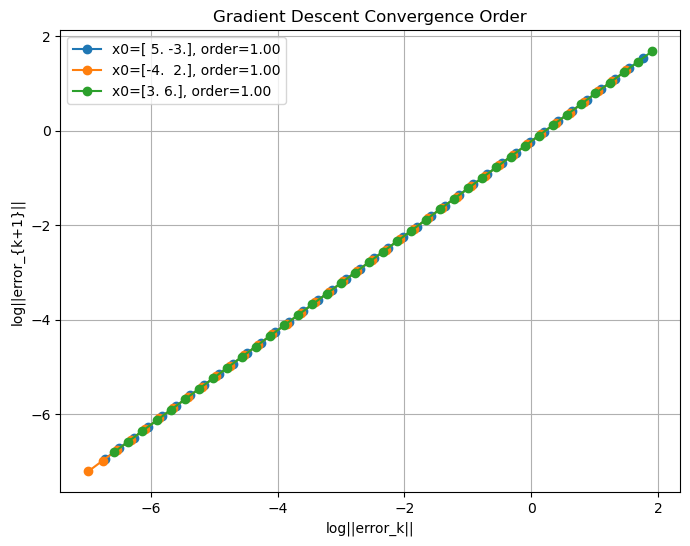

In [2]:
TestGradientDescent()

## Exercise 1

Compute the gradient of
$$ f(x,y,z) = x^2ye^{xz} +z\cos(xy)$$

#### The gradient of  
The gradient of  
$f(x,y,z) = x^2 y e^{xz} + z\cos(xy)$ is:

$$
\frac{\partial f}{\partial x}
= xy\, e^{xz}(2 + xz) - yz \sin(xy)
$$

$$
\frac{\partial f}{\partial y}
= x^2 e^{xz} - xz \sin(xy)
$$

$$
\frac{\partial f}{\partial z}
= x^3 y\, e^{xz} + \cos(xy)
$$

## Exercise 2
Compute the first two step of the gradient descent by hand and find the best learning rate
$$f(x,y) = 2x^4y^2,\; x_0=1,y_0=2$$

#### 1. Compute the gradient

$f(x,y)=2x^4y^2$

$$
\frac{\partial f}{\partial x}=8x^3y^2,\qquad
\frac{\partial f}{\partial y}=4x^4y
$$

At $(x_0,y_0)=(1,2)$:

$$
\nabla f(1,2)=(32,\;8).
$$

---

#### A. Two steps with $\alpha=0.1$

**Step 1**

$$
x_1=x_0-\alpha\frac{\partial f}{\partial x}\bigg|_{(1,2)}
=1-0.1\cdot 32=-2.2
$$

$$
y_1=y_0-\alpha\frac{\partial f}{\partial y}\bigg|_{(1,2)}
=2-0.1\cdot 8=1.2
$$


**Step 2**

$$
x_2=x_1-\alpha\frac{\partial f}{\partial x}\bigg|_{(x_1,y_1)}
=-2.2-0.1(-122.66496)\approx 10.066496
$$

$$
y_2=y_1-\alpha\frac{\partial f}{\partial y}\bigg|_{(x_1,y_1)}
=1.2-0.1(112.44288)\approx -10.044288
$$

---

#### B. Two steps with $\alpha=0.05$

**Step 1**

$$
x_1=1-0.05\cdot 32=-0.6
$$

$$
y_1=2-0.05\cdot 8=1.6
$$

**Step 2**

$$
x_2=-0.6-0.05(-4.42368)\approx -0.378816
$$

$$
y_2=1.6-0.05(0.82944)\approx 1.558528
$$

## Exercise 3
Minimize the function below
$$D(x_1,x_2)=2x_1^2 + 2x_1x_2 + 2x_2^2 -\sqrt{6}x_1 $$

In [3]:
# Gradient of D
def D_prime(v):
    x1, x2 = v
    return np.array([
        4*x1 + 2*x2 - np.sqrt(6),
        2*x1 + 4*x2
    ])

# Initial guess
x0 = [1.0, 1.0]

# Parameters
alpha = 0.1
N = 1000
small = 1e-8

# Run your gradient descent
xmin, iterations, grad_at_min = gradient_descent(D_prime, x0, alpha, N, small)

print("Approximate minimum point:", xmin)
print("Number of iterations:", iterations)
print("Gradient at minimum:", grad_at_min)

Approximate minimum point: [ 0.81649655 -0.40824826]
Number of iterations: 76
Gradient at minimum: [-5.28304902e-08  5.28304902e-08]


# Exercise 4
Minimize the function
$$ f(x_1,x_2) = (1-2x_2)^2+(x_1-2x_2^2)^2-2$$

In [4]:
# Gradient of f
def f_prime(v):
    x1, x2 = v
    df_dx1 = 2 * (x1 - 2 * x2**2)
    df_dx2 = 2 * (1 - 2*x2) * (-2) + 2 * (x1 - 2*x2**2) * (-4*x2)
    return np.array([df_dx1, df_dx2])

# initial guess and parameters
x0 = [0.4, 0.2]     
alpha = 0.1
N = 20000
small = 1e-8

xmin, iters, grad_at_min = gradient_descent(f_prime, x0, alpha, N, small)

print("Found minimizer:", xmin)
print("Iterations:", iters)
print("Gradient at minimizer:", grad_at_min)

Found minimizer: [0.49999991 0.49999998]
Iterations: 146
Gradient at minimizer: [-8.62672459e-08 -2.29095118e-08]


## Exercise 5
Minimize the function
$$ f(x,y) = 2x^2–4xy+5y^2−4y+3$$

In [5]:
# Gradient of f(x,y)
def f_prime(v):
    x, y = v
    df_dx = 4*x - 4*y
    df_dy = -4*x + 10*y - 4
    return np.array([df_dx, df_dy])

# Initial guess
x0 = [1.0, 1.0]
alpha = 0.01
N = 5000
small = 1e-10

xmin, iters, grad_at_min = gradient_descent(f_prime, x0, alpha, N, small)

print("Point reached:", xmin)
print("Iterations:", iters)
print("Gradient at point:", grad_at_min)

Point reached: [0.66666667 0.66666667]
Iterations: 908
Gradient at point: [8.63707594e-09 4.31853664e-09]


## Exercise 6
Assume you the following data
| Size (sq. ft.) | Age (years) | Price ($1000s) |
|----------------|-------------|----------------|
| 1500 | 5 | 300 |
| 2000 | 10 | 350 |
| 1200 | 2 | 250 |
| 1800 | 8 | 320 |
| 2200 | 15 | 380 |
| 1600 | 3 | 290 |
| 2500 | 20 | 400 |
| 1900 | 12 | 340 |
| 1700 | 7 | 310 |


Compute by hand the error for linear regression model
$$(Price) y = 0.1\cdot Size + 2\cdot Age +100$$

### By hand 

$$E_1 = 300 - (0.1\cdot1500 + 2\cdot5 + 100) = 40,\qquad E_1^2 = 1600$$

$$E_2 = 350 - (0.1\cdot2000 + 2\cdot10 + 100) = 30,\qquad E_2^2 = 900$$

$$E_3 = 250 - (0.1\cdot1200 + 2\cdot2 + 100) = 26,\qquad E_3^2 = 676$$

$$E_4 = 320 - (0.1\cdot1800 + 2\cdot8 + 100) = 24,\qquad E_4^2 = 576$$

$$E_5 = 380 - (0.1\cdot2200 + 2\cdot15 + 100) = 30,\qquad E_5^2 = 900$$

$$E_6 = 290 - (0.1\cdot1600 + 2\cdot3 + 100) = 24,\qquad E_6^2 = 576$$

$$E_7 = 400 - (0.1\cdot2500 + 2\cdot20 + 100) = 10,\qquad E_7^2 = 100$$

$$E_8 = 340 - (0.1\cdot1900 + 2\cdot12 + 100) = 26,\qquad E_8^2 = 676$$

$$E_9 = 310 - (0.1\cdot1700 + 2\cdot7 + 100) = 26,\qquad E_9^2 = 676$$

### Sum of Squared Errors

$$
\sum_{i=1}^9 E_i^2 
= 1600 + 900 + 676 + 576 + 900 + 576 + 100 + 676 + 676 
= 6080.
$$

### Final Error

$$
\boxed{
\text{Error} 
= \frac{6080}{9} 
\approx 742.22
}
$$


## Exercise 7
The file `car_efficiency.csv` contains the MPGs and the weights
of different cars.
1. Plot as a scatter plot the data
2. Find the linear regression model, this means, let x=MPG of
the ith car and y=weight of the ith car.
$$y_i \approx m\cdot x_i + b$$
1. Find the quadratic regression model, this means.
$$y_i \approx m_2\cdot x_i^2+ m_1\cdot x_i + b$$
1. Plot the scatter plot of the data with the regression line.
2. Estimate the weight of a car if the mileage is 32 MPG
To read the file use the following command:
```python
import pandas as pd
df = pd.read_csv("car_efficiency.csv") # read the csv file and
put the data into the data frame df
values = df.values # puit all the values of the data frame into
an array values, where the first column is x and the second colum
is y
x = values[:,0]
y = values[:,1]
```

In [6]:
df = pd.read_csv("/Users/hecto129039/Downloads/car_efficiency.csv")
values = df.values
x = values[:,0]   # MPG
y = values[:,1]   # Weight
n = len(x)

In [7]:
def grad_linear(v):
    m, b = v
    y_pred = m*x + b
    error = y_pred - y

    dm = (2/n) * np.sum(error * x)
    db = (2/n) * np.sum(error)
    return np.array([dm, db])

# initial guess
v0 = [0, 0]
alpha = 0.001   # learning rate
N = 500000
small = 1e-8

(linear_params, steps_lin, _) = gradient_descent(grad_linear, v0, alpha, N, small)
m, b = linear_params

print("Linear regression (gradient descent)")
print(f"m = {m:.6f}, b = {b:.6f}, steps = {steps_lin}")

Linear regression (gradient descent)
m = -68.783290, b = 3112.795925, steps = 205225


In [8]:
def grad_quadratic(v):
    m2, m1, b = v
    y_pred = m2*x**2 + m1*x + b
    error = y_pred - y

    dm2 = (2/n) * np.sum(error * x**2)
    dm1 = (2/n) * np.sum(error * x)
    db  = (2/n) * np.sum(error)
    return np.array([dm2, dm1, db])

# initial guess
v0q = [0, 0, 0]
alpha = 0.000001   # learning rate
N = 500000
small = 1e-8

(quadratic_params, steps_quad, _) = gradient_descent(grad_quadratic, v0q, alpha, N, small)
m2, m1, b2 = quadratic_params

print("\nQuadratic regression (gradient descent)")
print(f"m2 = {m2:.6f}, m1 = {m1:.6f}, b = {b2:.6f}, steps = {steps_quad}")



Quadratic regression (gradient descent)
m2 = -6.904506, m1 = 229.166021, b = 28.371253, steps = 500000


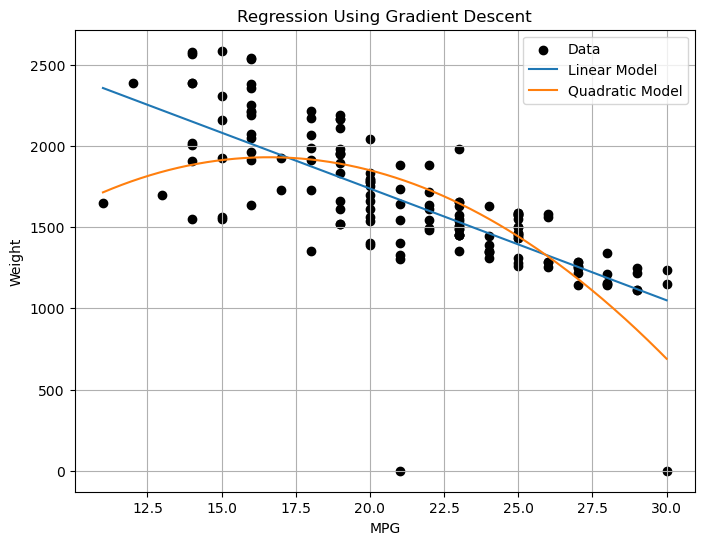

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='black', label="Data")

x_plot = np.linspace(min(x), max(x), 300)

# linear
plt.plot(x_plot, m*x_plot + b, label="Linear Model")

# quadratic
plt.plot(x_plot, m2*x_plot**2 + m1*x_plot + b2, label="Quadratic Model")

plt.xlabel("MPG")
plt.ylabel("Weight")
plt.title("Regression Using Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
mpg_test = 32

lin_prediction  = m*mpg_test + b
quad_prediction = m2*mpg_test**2 + m1*mpg_test + b2

print("\nPredicted weight at 32 MPG:")
print(f"Linear model:   {lin_prediction:.4f}")
print(f"Quadratic model:{quad_prediction:.4f}")


Predicted weight at 32 MPG:
Linear model:   911.7306
Quadratic model:291.4698


## Exercise 8
Find a data set with at least 2 feature (this means x has to be
of dimension 2 or more) and find the linear regression line to
predict the label y.


In [11]:
df = pd.read_csv("/Users/hecto129039/Downloads/synthetic_dataset.csv")

In [12]:
X1 = df["X1"].values
X2 = df["X2"].values
y  = df["y"].values
n = len(df)

# Put features into matrix form
X = np.column_stack([X1, X2])

In [13]:
def grad_linear(v):
    b, w1, w2 = v

    y_pred = b + w1*X[:,0] + w2*X[:,1]
    error = y_pred - y

    db  = (2/n) * np.sum(error)
    dw1 = (2/n) * np.sum(error * X[:,0])
    dw2 = (2/n) * np.sum(error * X[:,1])

    return np.array([db, dw1, dw2])


In [14]:
v0 = [0, 0, 0]
alpha = 0.0005
N = 500000
small = 1e-8

(params, steps, _) = gradient_descent(grad_linear, v0, alpha, N, small)

b, w1, w2 = params

print("Linear Regression")
print(f"b  = {b:.6f}")
print(f"w1 = {w1:.6f}")
print(f"w2 = {w2:.6f}")
print(f"Steps: {steps}")

print("\nRegression model found:")
print(f"y = {w1:.4f}*X1 + {w2:.4f}*X2 + {b:.4f}" )


Linear Regression
b  = 2.990183
w1 = 1.965709
w2 = -1.449016
Steps: 103189

Regression model found:
y = 1.9657*X1 + -1.4490*X2 + 2.9902


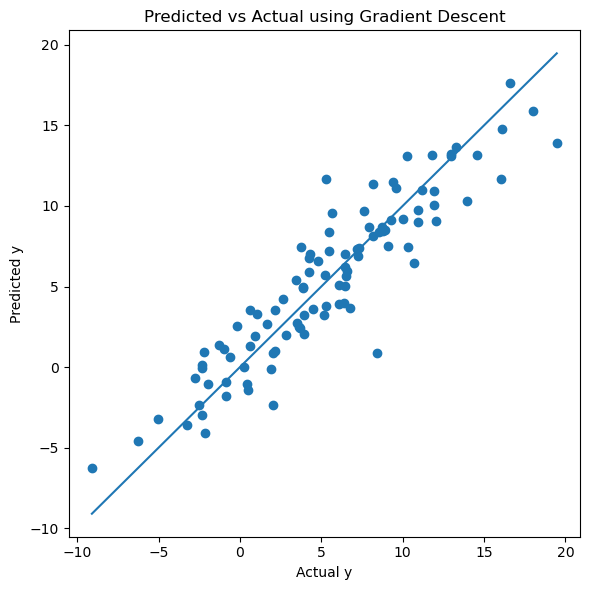

In [15]:
y_pred = b + w1*X1 + w2*X2

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Predicted vs Actual using Gradient Descent")
plt.tight_layout()
plt.show()

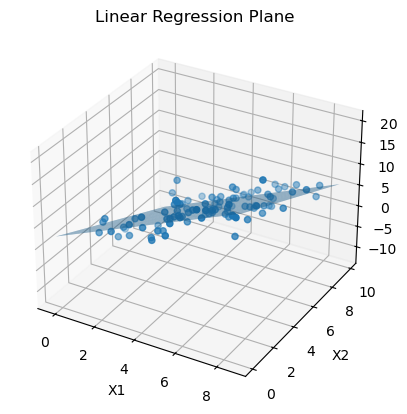

In [16]:
x1_grid = np.linspace(X1.min(), X1.max(), 30)
x2_grid = np.linspace(X2.min(), X2.max(), 30)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)

Yg = b + w1*X1g + w2*X2g

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Scatter data points
ax.scatter(X1, X2, y)

# Regression plane
ax.plot_surface(X1g, X2g, Yg, alpha=0.5)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.set_title("Linear Regression Plane")

plt.show()
